In [301]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics 
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import math
import warnings
import xgboost as xgb
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
#!pip install statsmodels
#!pip install xgboost
import statsmodels.api as sm
%matplotlib inline

In [302]:
## Data

In [303]:
df = pd.read_pickle("df_after_feature_eng_1.pkl")
print(df.isnull().sum())  # Should match the saved df

track_id                         0
track_popularity                 0
track_album_id                   0
danceability                     0
energy                           0
key                              0
loudness                         0
mode                             0
speechiness                      0
acousticness                     0
instrumentalness                 0
liveness                         0
valence                          0
tempo                            0
playlist_count_per_song          0
duration_minutes                 0
playlist_genre_count_per_song    0
track_album_release_year         0
track_album_release_month        0
instrumentalness_log             0
language_category                0
track_artist_type                0
dtype: int64


In [304]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  string 
 1   track_popularity               32833 non-null  float64
 2   track_album_id                 32833 non-null  string 
 3   danceability                   32833 non-null  float64
 4   energy                         32833 non-null  float64
 5   key                            32833 non-null  float64
 6   loudness                       32833 non-null  float64
 7   mode                           32833 non-null  float64
 8   speechiness                    32833 non-null  float64
 9   acousticness                   32833 non-null  float64
 10  instrumentalness               32833 non-null  float64
 11  liveness                       32833 non-null  float64
 12  valence                        32833 non-null 

In [305]:
### Encoding Categorial 

In [306]:
 ## transforming object and encoding 

In [307]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Process all object or string columns
for column in df.columns:
    if df[column].dtype == 'object' or df[column].dtype == 'string':  # Check for object or string type
        df.loc[:, column] = label_encoder.fit_transform(df[column].astype(str))  # Apply LabelEncoder


In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  int32  
 1   track_popularity               32833 non-null  float64
 2   track_album_id                 32833 non-null  int32  
 3   danceability                   32833 non-null  float64
 4   energy                         32833 non-null  float64
 5   key                            32833 non-null  float64
 6   loudness                       32833 non-null  float64
 7   mode                           32833 non-null  float64
 8   speechiness                    32833 non-null  float64
 9   acousticness                   32833 non-null  float64
 10  instrumentalness               32833 non-null  float64
 11  liveness                       32833 non-null  float64
 12  valence                        32833 non-null 

In [309]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['language_category'] = label_encoder.fit_transform(df['language_category'].astype(str))
df['track_artist_type'] = label_encoder.fit_transform(df['track_artist_type'].astype(str))


In [310]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       32833 non-null  int32  
 1   track_popularity               32833 non-null  float64
 2   track_album_id                 32833 non-null  int32  
 3   danceability                   32833 non-null  float64
 4   energy                         32833 non-null  float64
 5   key                            32833 non-null  float64
 6   loudness                       32833 non-null  float64
 7   mode                           32833 non-null  float64
 8   speechiness                    32833 non-null  float64
 9   acousticness                   32833 non-null  float64
 10  instrumentalness               32833 non-null  float64
 11  liveness                       32833 non-null  float64
 12  valence                        32833 non-null 

In [311]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_id,32833.0,14214.298480,8197.512909,0.000,7111.0000,14214.000000,21354.000000,28355.000000
track_popularity,32833.0,42.477081,24.984074,0.000,24.0000,45.000000,62.000000,100.000000
track_album_id,32833.0,11248.474979,6495.932017,0.000,5619.0000,11227.000000,16854.000000,22544.000000
danceability,32833.0,0.672778,0.095117,0.464,0.6050,0.678000,0.743600,0.860000
energy,32833.0,0.732267,0.129313,0.452,0.6390,0.738000,0.833000,0.969000
key,32833.0,5.374471,3.611657,0.000,2.0000,6.000000,9.000000,11.000000
loudness,32833.0,-6.071534,1.666042,-9.934,-7.2380,-5.952000,-4.819000,-2.883000
mode,32833.0,0.565711,0.495671,0.000,0.0000,1.000000,1.000000,1.000000
speechiness,32833.0,0.066141,0.033784,0.000,0.0406,0.056400,0.082100,0.177000
acousticness,32833.0,0.092405,0.093321,0.000,0.0146,0.063300,0.140200,0.374000


In [312]:
#df.isna().sum()

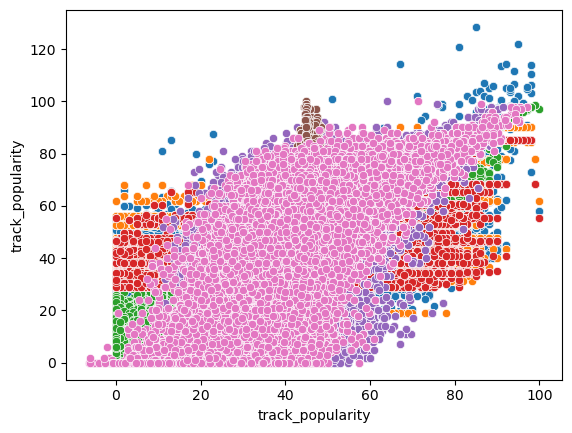

In [313]:
import matplotlib.pyplot as plt

plt.show()

In [314]:
df.corr(method='spearman')

,track_id,track_popularity,track_album_id,danceability,energy,key,loudness,mode,speechiness,acousticness,...,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song,track_album_release_year,track_album_release_month,instrumentalness_log,language_category,track_artist_type
track_id,1.000000,0.017813,-0.010323,0.006505,-0.016029,-0.006436,-0.009105,-0.007783,0.002948,0.020273,...,0.001311,-0.005932,0.013196,0.004132,0.013954,0.007461,0.011258,-0.008787,0.010688,-0.009750
track_popularity,0.017813,1.000000,-0.000442,0.051165,-0.105215,-0.001367,0.053153,0.012607,0.011991,0.128376,...,0.037220,-0.022321,0.450012,-0.120712,0.430558,0.176053,0.083211,-0.193198,0.015083,-0.048443
track_album_id,-0.010323,-0.000442,1.000000,0.000577,0.004169,0.007132,0.004626,0.000166,-0.005203,0.004431,...,-0.000419,0.000118,-0.008199,-0.019127,-0.004086,0.005351,-0.001835,0.010344,-0.007858,-0.010857
danceability,0.006505,0.051165,0.000577,1.000000,-0.130792,0.011184,-0.045921,-0.042578,0.188968,0.130542,...,0.245488,-0.129949,0.034252,-0.043769,0.019722,0.096178,0.038488,-0.028065,0.077928,-0.001995
energy,-0.016029,-0.105215,0.004169,-0.130792,1.000000,-0.001394,0.439183,0.010979,0.065871,-0.293620,...,0.067821,0.134125,-0.030870,-0.015564,-0.023081,-0.042637,-0.043357,0.144131,-0.029971,0.051831
key,-0.006436,-0.001367,0.007132,0.011184,-0.001394,1.000000,-0.008654,-0.168570,0.020010,0.010362,...,0.018439,-0.015870,0.008885,0.012960,0.002730,0.000010,0.007482,0.011859,0.005121,0.000250
loudness,-0.009105,0.053153,0.004626,-0.045921,0.439183,-0.008654,1.000000,-0.017491,0.110915,-0.134902,...,0.024788,0.084456,0.087136,-0.117811,0.086328,0.145417,0.027906,-0.089516,0.020370,0.041844
mode,-0.007783,0.012607,0.000166,-0.042578,0.010979,-0.168570,-0.017491,1.000000,-0.074879,-0.017342,...,0.002363,0.011231,-0.005014,0.018229,0.003638,-0.067933,-0.032240,-0.013331,-0.015431,-0.015639
speechiness,0.002948,0.011991,-0.005203,0.188968,0.065871,0.020010,0.110915,-0.074879,1.000000,0.020793,...,0.061129,0.050161,0.017290,-0.128184,0.007238,0.171064,0.057735,-0.114761,0.067807,0.048793
acousticness,0.020273,0.128376,0.004431,0.130542,-0.293620,0.010362,-0.134902,-0.017342,0.020793,1.000000,...,0.146512,-0.144219,0.050810,-0.060119,0.033025,0.051290,0.029832,-0.261902,0.077995,-0.067423


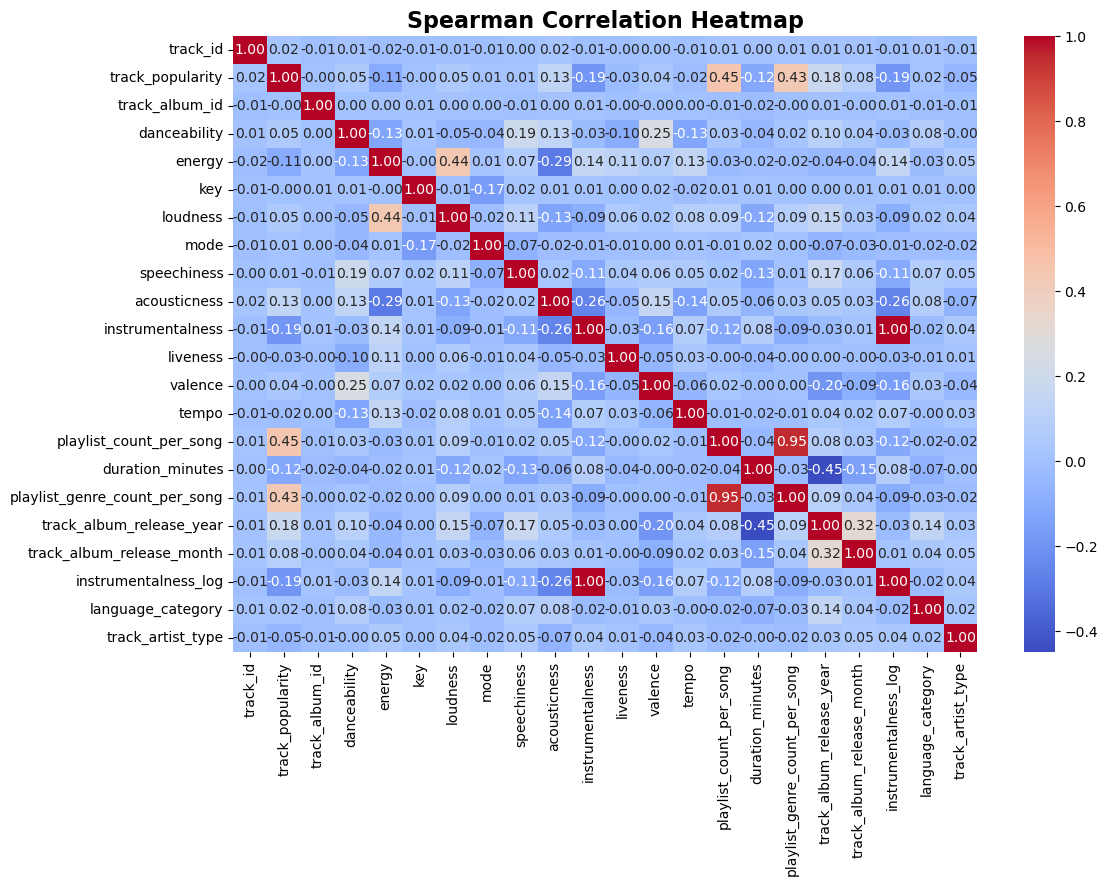

In [315]:

# Calculate the Spearman correlation matrix
spearman_corr = df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Heatmap', fontsize=16, fontweight='bold')  # Add a title
plt.show()


In [316]:
def regressionMetrics(y, yhat):
    res = {'MSE': metrics.mean_squared_error(y,yhat),
           'RMSE': np.sqrt(metrics.mean_squared_error(y,yhat)),
           'MAE': metrics.mean_absolute_error(y,yhat),
           'RMSLE': np.sqrt(metrics.mean_squared_log_error(y,yhat)),
           'r2' :   r2_score(y, yhat)
          }
    return res

In [317]:
## Regression Models

In [318]:
print(xgboost.__version__)

1.6.2


In [319]:
models_list = pd.DataFrame()

In [320]:
### Linear Regression

In [321]:
mod1 = LinearRegression()
mod1.fit(X,y)

pred1 = mod1.predict(X)

In [322]:
regressionMetrics(y, pred1)

{'MSE': 479.5771160888861,
 'RMSE': 21.89924921290422,
 'MAE': 18.24968998231655,
 'RMSLE': 1.2711578451230443,
 'r2': 0.231674676792197}

In [323]:
model_dict = {'model': "Linear Regression"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred1)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.24969,1.271158,0.231675


In [324]:
sns.scatterplot(x=y, y=pred1)

<Axes: xlabel='track_popularity'>

### Decision Tree

In [325]:
from sklearn.tree import DecisionTreeRegressor
mod2 = DecisionTreeRegressor(max_depth=5)  
mod2.fit(X, y)


DecisionTreeRegressor(max_depth=5)

In [326]:
pred2 = mod2.predict(X)
model_dict = {'model': "Decision Tree"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred2)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.24969,1.271158,0.231675
1,Decision Tree,445.984669,21.118349,17.36239,1.237097,0.285493


In [327]:
sns.scatterplot(x=y, y=pred2)


<Axes: xlabel='track_popularity'>

### Random Forest

In [328]:
mod3 = RandomForestRegressor(random_state=1)
mod3.fit(X,y)

RandomForestRegressor(random_state=1)

In [329]:
pred3 = mod3.predict(X)
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred3)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.249690,1.271158,0.231675
1,Decision Tree,445.984669,21.118349,17.362390,1.237097,0.285493
2,RandomForest,50.686310,7.119432,5.452068,0.798176,0.918796


In [330]:
sns.scatterplot(x=y, y=pred3)

<Axes: xlabel='track_popularity'>

### Adaptive Boosting (ADABoost)

In [331]:
mod4 = AdaBoostRegressor(random_state=1)
mod4.fit(X,y)

AdaBoostRegressor(random_state=1)

In [332]:
pred4 = mod4.predict(X)
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred4)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.249690,1.271158,0.231675
1,Decision Tree,445.984669,21.118349,17.362390,1.237097,0.285493
2,RandomForest,50.686310,7.119432,5.452068,0.798176,0.918796
3,ADABoost,467.518011,21.622165,18.322924,1.251721,0.250994


In [333]:
sns.scatterplot(x=y, y=pred4)

<Axes: xlabel='track_popularity'>

In [334]:
### Gradient Boosting Machine (GBM)

In [335]:
mod5 = GradientBoostingRegressor(random_state=1)
mod5.fit(X,y)

GradientBoostingRegressor(random_state=1)

In [336]:
pred5 = mod5.predict(X)
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred5)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.249690,1.271158,0.231675
1,Decision Tree,445.984669,21.118349,17.362390,1.237097,0.285493
2,RandomForest,50.686310,7.119432,5.452068,0.798176,0.918796
3,ADABoost,467.518011,21.622165,18.322924,1.251721,0.250994
4,GBM,421.075525,20.520125,16.861705,1.223674,0.325399


In [337]:
sns.scatterplot(y=y, x=pred5)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [338]:
### Support Vector Machine (SVM)

In [339]:
mod6 = SVR()
mod6.fit(X,y)


SVR()

In [340]:
pred6 = mod6.predict(X)
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred6)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,479.577116,21.899249,18.249690,1.271158,0.231675
1,Decision Tree,445.984669,21.118349,17.362390,1.237097,0.285493
2,RandomForest,50.686310,7.119432,5.452068,0.798176,0.918796
3,ADABoost,467.518011,21.622165,18.322924,1.251721,0.250994
4,GBM,421.075525,20.520125,16.861705,1.223674,0.325399
5,SVM,631.554578,25.130750,20.760336,1.357186,-0.011807


In [341]:
sns.scatterplot(y=y, x=pred6)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [342]:
print(df[df['track_popularity'] < 0])  # Filters and prints rows where track_popularity is negative


Empty DataFrame
Columns: [track_id, track_popularity, track_album_id, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, playlist_count_per_song, duration_minutes, playlist_genre_count_per_song, track_album_release_year, track_album_release_month, instrumentalness_log, language_category, track_artist_type]
Index: []

[0 rows x 22 columns]


# XGBoost Regressor

In [343]:
df['track_popularity'].min()

0.0

In [344]:
mod7= xgb.XGBRegressor()
mod7.fit(X,y)

XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [355]:
sns.scatterplot(y=y, x=pred7)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [356]:
#Checking for Negative Values

#print(y[y < 0])  # Check negative values in y
#print(pred7[pred7 < 0])  # Check negative values in predictions


In [357]:
print(y[y < 0])  # Check for negative values in y
print(pred7[pred7 < 0])  # Check for negative values in predictions


Series([], Name: track_popularity, dtype: float64)
[-0.3267889  -1.5114932  -1.4764514  -0.27746302 -5.503471   -0.04081833
 -6.435588   -2.702914   -4.0320745  -4.3761673  -0.21567364 -5.161395
 -0.5715965  -0.8210232  -0.86887324 -0.9121202  -2.14866    -6.1724434
 -0.01246944 -6.2036347  -3.9212577  -2.4639015  -0.64451444 -2.7665646 ]


In [358]:
pred7 = mod7.predict(X)
model_dict = {'model': "XGB"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred7)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

ValueError: Mean Squared Logarithmic Error cannot be used when targets contain negative values.

In [349]:
mod7= xgb.XGBRegressor()
mod7.fit(X,y)


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=0, reg_alpha=0,
             reg_lambda=1, ...)

In [350]:
pred7 = mod7.predict(X)
model_dict = {'model': "XGB"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred7)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

ValueError: Mean Squared Logarithmic Error cannot be used when targets contain negative values.

In [ ]:
Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

## Model Selection

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [ ]:
models_list.sort_values('MAE')

In [ ]:
models_list.sort_values('RMSE')

In [ ]:
# Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100, 200],  # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider at every split
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
}

# Create a base model
rf = RandomForestRegressor()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2)
#Verbose - level of details that will be provided in each iteration
# Fit the grid search to the data
grid_search.fit(X, y)

In [ ]:
# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", -grid_search.best_score_)

In [351]:
# XGBoost Finetuning

In [352]:
<b>Fitting x folds</b> Performing x-fold <br><b>Candidates</b>cross-validation on numner of hyperparameter combinations <br><b>Totalling</b> resulting in 1,944 total model training and evaluation runs.

SyntaxError: invalid syntax (38917367.py, line 1)

In [353]:
grid_search = GridSearchCV(estimator=mod7, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)


Fitting 3 folds for each of 648 candidates, totalling 1944 fits



KeyboardInterrupt



In [ ]:
print("Best Score (RMSLE):", -grid_search.best_score_)

In [ ]:
pred8 = grid_search.predict(X)
model_dict = {'model': "Random_Forest_FT"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred8)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

In [ ]:
### Comparisson

In [ ]:
print('Improvement of {:0.2f}%.'.format( 100 * (base_accuracy - random_accuracy) / base_accuracy))

In [ ]:
df.to_pickle ("SOPOTIFY_MODEL_SELECTION.pkl")